# EXP 003: Teórico x Experimental
---

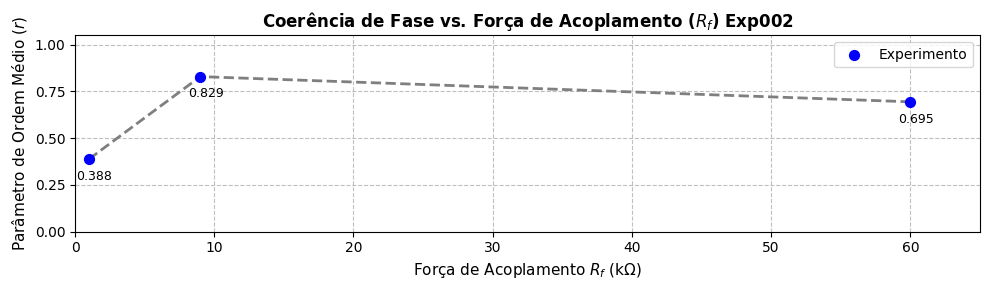

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# --- FUNÇÃO PARA CALCULAR O PARÂMETRO DE ORDEM ---
def order_parameter(signal_matrix):
    analytic_signal = hilbert(signal_matrix, axis=0)
    phases = np.angle(analytic_signal)
    r_complex = np.mean(np.exp(1j * phases), axis=1)
    return np.abs(r_complex)

# --- ARQUIVOS E FORÇAS DE ACOPLAMENTO ---
files = ['exp003a.csv', 'exp003b.csv', 'exp003c.csv']
Rf_values = np.array([1000, 9000, 60000])  # em Ohms
tempo_de_corte = 10.0  # segundos iniciais descartados

r_means = []

for file in files:
    data = pd.read_csv(file, header=None)
    
    # Detecta número de osciladores
    num_osc = data.shape[1] - 1
    osciladores = [f'oscilador_{i+1}' for i in range(num_osc)]
    data.columns = ['tempo'] + osciladores
    
    # Filtra sinal estável
    data_estavel = data[data['tempo'] >= tempo_de_corte].reset_index(drop=True)
    
    # Calcula parâmetro de ordem
    signals = data_estavel[osciladores].values
    r = order_parameter(signals)
    
    # Média
    r_means.append(np.mean(r))

# --- PLOTAR r MÉDIO vs Rf ---
plt.figure(figsize=(10, 3))

# Bolinhas
plt.scatter(Rf_values/1000, r_means, color='blue', s=50, zorder=3, label="Experimento")

# Linha tracejada conectando os pontos
plt.plot(Rf_values/1000, r_means, linestyle='--', color='tab:gray', linewidth=2)

# Anotações dos valores médios
for x, y in zip(Rf_values/1000, r_means):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                 xytext=(4, -15), ha='center', fontsize=9, color='black')

plt.title("Coerência de Fase vs. Força de Acoplamento ($R_f$) Exp002", fontsize=12, weight='bold')
plt.xlabel("Força de Acoplamento $R_f$ (kΩ)", fontsize=11)
plt.ylabel("Parâmetro de Ordem Médio ($r$)", fontsize=11)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, 0.25))  # <-- aqui estão as marcações
plt.xlim(0, max(Rf_values/1000)+5)
plt.grid(True, linestyle='--', alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()


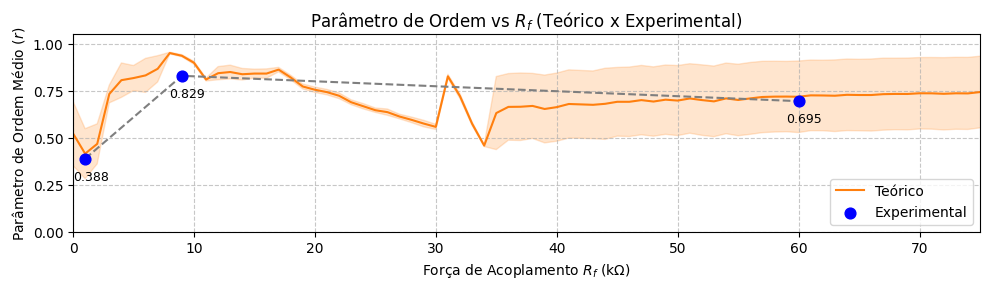

In [36]:
import numpy as np, scipy as sp, matplotlib.pyplot as plt, os
import pandas as pd
from scipy.signal import hilbert
import quadratureNetwork as qnet #library that implement the oscillators

# --- DADOS TEÓRICOS ---
folderName = 'exp003'
allFiles = os.listdir(folderName)

Rf = []
pcMean = []
pcStd = []
x_max = []

for file in allFiles:
    if file[-3:] == 'mat':
        npzfile = sp.io.loadmat(folderName+'\\'+file)
        Rf.append(npzfile['Rf'][0,0])
        pcMean.append(npzfile['pcMean'][0,0])
        pcStd.append(npzfile['pcStd'][0,0])
        x_max.append(np.max(np.abs(npzfile['x'][:,::3])))

Rf = np.array(Rf)
pcMean = np.array(pcMean)
pcStd = np.array(pcStd)
sorIdx = np.argsort(Rf)
x_max = np.array(x_max)
Rf, pcMean, pcStd = Rf[sorIdx], pcMean[sorIdx], pcStd[sorIdx]

# --- DADOS EXPERIMENTAIS ---
def order_parameter(signal_matrix):
    analytic_signal = hilbert(signal_matrix, axis=0)
    phases = np.angle(analytic_signal)
    r_complex = np.mean(np.exp(1j * phases), axis=1)
    return np.abs(r_complex)

files = ['exp003a.csv', 'exp003b.csv', 'exp003c.csv']
Rf_values = np.array([1000, 9000, 60000])  # em Ohms
tempo_de_corte = 10.0

r_means = []
for file in files:
    data = pd.read_csv(file, header=None)
    num_osc = data.shape[1] - 1
    osciladores = [f'oscilador_{i+1}' for i in range(num_osc)]
    data.columns = ['tempo'] + osciladores
    data_estavel = data[data['tempo'] >= tempo_de_corte].reset_index(drop=True)
    signals = data_estavel[osciladores].values
    r = order_parameter(signals)
    r_means.append(np.mean(r))

# --- PLOTAGEM UNIFICADA ---
plt.figure(figsize=(10,3))
plt.title(r'Parâmetro de Ordem vs $R_f$ (Teórico x Experimental)')

# Teórico
plt.plot(Rf/1000, pcMean, '-', color='tab:orange', label='Teórico')
plt.fill_between(Rf/1000, pcMean-pcStd, pcMean+pcStd, color='tab:orange', alpha=0.2)

# Experimental
plt.scatter(Rf_values/1000, r_means, color='blue', s=60, zorder=3, label="Experimental")
plt.plot(Rf_values/1000, r_means, linestyle='--', color='tab:gray', linewidth=1.5)

# Marcação de pontos experimentais com valores
for x, y in zip(Rf_values/1000, r_means):
    plt.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                 xytext=(4, -15), ha='center', fontsize=9, color='black')

plt.xlabel(r"Força de Acoplamento $R_f$ (k$\Omega$)")
plt.ylabel("Parâmetro de Ordem Médio ($r$)")
plt.xlim(0, 75) 
# plt.xlim(0e3, 75e3) é com os valorem em Kohms
#plt.xlim(0, max(Rf_values/1000)+5)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.25, 0.25))  # <<<<<< aqui
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

